# 🇰🇷 → 🇺🇸 Transformer 한·영 번역기  

한국어 문장을 영어로 번역하는 **Transformer 번역기**  구현하기  

## 학습 목표  

- 테스트 결과 의미가 통하는 수준의 번역문이 생성되었다
  
- Transformer 번역기 모델이 정상적으로 구동된다
  
- 번역기 모델 학습에 필요한 텍스트 데이터 전처리가 잘 이루어졌다
  
## 평가 기준  

- 제시된 문장에 대한 그럴듯한 영어 번역문이 생성되며, 시각화된 Attention Map 으로 결과를 뒷받침한다

- Transformer 모델의 학습과 추론 과정이 정상적으로 진행되어, 한-영 번역기능이 정상 작동한다

- 데이터 정제, SentencePiece 를 활용한 토큰화 및 데이터셋 구축의 과정이 지시대로 진행되었다


## 1. 라이브러리 설치와 기본 설정

In [2]:
!pip install -q sentencepiece sacrebleu

In [3]:
import json
import math
import random
import re
import tarfile
import time
import urllib.request
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import sentencepiece as spm
import sacrebleu

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader


# 랜덤 시드
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():

    torch.cuda.manual_seed_all(SEED)

# GPU가 있으면 cuda, 없으면 cpu
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 결과 출력
print('PyTorch version :', torch.__version__)
print('사용 장치        :', DEVICE)

if DEVICE.type == 'cuda':
    print('GPU 이름         :', torch.cuda.get_device_name(0))


PyTorch version : 2.7.1+cu118
사용 장치        : cuda
GPU 이름         : Tesla T4


하이퍼파라미터와 저장 경로 설정

In [4]:
# 전체 학습을 할지 빠른 확인만 할지 정한다
QUICK_RUN = False

# 프로젝트 파일을 모아둘 폴더
PROJECT_DIR = Path.home() / 'work' / 'ko_en_transformer'
# 다운로드한 데이터를 저장할 폴더
DATA_DIR = PROJECT_DIR / 'data'
# SentencePiece 모델을 저장할 폴더
TOKENIZER_DIR = PROJECT_DIR / 'tokenizer'
# 학습된 번역 모델을 저장할 폴더
MODEL_DIR = PROJECT_DIR / 'model'

for directory in [DATA_DIR, TOKENIZER_DIR, MODEL_DIR]:
    # 폴더가 없으면 자동 생성
    directory.mkdir(parents=True, exist_ok=True)

# 한국어 영어 문장에서 사용할 최대 토큰 길이
MAX_LEN = 64
# 한국어 토크나이저가 사용할 단어 조각 개수
SRC_VOCAB_SIZE = 16_000
# 영어 토크나이저가 사용할 단어 조각 개수
TGT_VOCAB_SIZE = 16_000

# 빠른 실행에서 사용할 학습 문장쌍 개수
MAX_TRAIN_PAIRS = 8_000 if QUICK_RUN else None
# 빠른 실행에서 사용할 검증 문장쌍 개수
MAX_VALID_PAIRS = 500 if QUICK_RUN else None
# 빠른 실행에서 사용할 테스트 문장쌍 개수
MAX_TEST_PAIRS = 200 if QUICK_RUN else None

# 토큰 하나를 표현할 임베딩 차원
D_MODEL = 128 if QUICK_RUN else 256
# Encoder와 Decoder를 쌓을 층 수
N_LAYERS = 2 if QUICK_RUN else 3
# Multi-Head Attention 머리 수
N_HEADS = 4 if QUICK_RUN else 8
# Feed Forward 안쪽 차원
D_FF = 512 if QUICK_RUN else 1024
# dropout, 과적합 방지용 작은 우산
DROPOUT = 0.1

# 한 번에 학습할 문장쌍 개수
BATCH_SIZE = 32 if QUICK_RUN else 64
# 최대 epoch 수, Early Stopping이 먼저 끊을 수 있다
EPOCHS = 2 if QUICK_RUN else 12
# 처음 학습률을 천천히 올릴 step 수
WARMUP_STEPS = 1_000 if QUICK_RUN else 4_000
# 검증 성능이 좋아지지 않을 때 기다리는 횟수
PATIENCE = 2 if QUICK_RUN else 3
# gradient가 너무 커지지 않게 막는 한계값
GRAD_CLIP = 1.0

# 가장 좋은 번역 모델을 저장할 경로
MODEL_PATH = MODEL_DIR / 'best_ko_en_transformer.pt'

# 결과 출력
print('프로젝트 폴더 :', PROJECT_DIR)
print('빠른 실행 모드 :', QUICK_RUN)
print('최대 토큰 길이 :', MAX_LEN)
print('모델 저장 경로 :', MODEL_PATH)


프로젝트 폴더 : /home/jovyan/work/ko_en_transformer
빠른 실행 모드 : False
최대 토큰 길이 : 64
모델 저장 경로 : /home/jovyan/work/ko_en_transformer/model/best_ko_en_transformer.pt


## 2. 한·영 병렬 말뭉치 다운로드

사용 데이터는 공개된 `korean-parallel-corpora`의 뉴스 병렬 말뭉치를 가져온다  

- train: 약 94,123 문장쌍
- dev: 1,000 문장쌍
- test: 2,000 문장쌍

데이터 출처: https://github.com/jungyeul/korean-parallel-corpora  

In [5]:
# 한영 병렬 데이터를 찾고 없으면 다운로드
# 한영 병렬 데이터를 받을 GitHub 주소
BASE_URL = (
    'https://raw.githubusercontent.com/'
    'jungyeul/korean-parallel-corpora/master/'
    'korean-english-news-v1'
)


# 압축 파일을 안전하게 푸는 함수
def safe_extract(tar, destination):
    # 압축을 풀 폴더의 실제 경로를 확인
    destination = destination.resolve()

    # 압축 안의 파일을 하나씩 확인
    for member in tar.getmembers():
        # 압축 파일이 만들어질 실제 경로 계산
        member_path = (destination / member.name).resolve()

        if destination not in member_path.parents and member_path != destination:
            # 문제가 있으면 이유를 보여주고 멈춘다
            raise RuntimeError(f'안전하지 않은 압축 경로: {member.name}')

    # 경로가 안전하면 압축을 푼다
    tar.extractall(destination)


# train, dev, test 데이터를 다운로드하는 함수
def download_parallel_corpus(split):
    # 한국어 파일이 저장될 경로
    ko_path = DATA_DIR / f'korean-english-park.{split}.ko'
    # 영어 파일이 저장될 경로
    en_path = DATA_DIR / f'korean-english-park.{split}.en'

    # 한국어 영어 파일이 이미 있는지 확인
    if ko_path.exists() and en_path.exists():
        # 결과 출력
        print(f'[{split}] 기존 파일 사용')
        # 결과 반환
        return ko_path, en_path

    # 압축 파일 이름 생성
    archive_name = f'korean-english-park.{split}.tar.gz'
    # 압축 파일 저장 경로 생성
    archive_path = DATA_DIR / archive_name
    # 현재 split의 다운로드 주소 생성
    archive_url = f'{BASE_URL}/{archive_name}'

    # 결과 출력
    print(f'[{split}] 다운로드 시작')
    # 인터넷에서 압축 파일을 받는다
    urllib.request.urlretrieve(archive_url, archive_path)

    # 결과 출력
    print(f'[{split}] 압축 해제')
    # 받은 tar.gz 파일을 연다
    with tarfile.open(archive_path, 'r:gz') as tar:
        safe_extract(tar, DATA_DIR)

    # 압축을 풀고 실제 파일이 생겼는지 확인
    if not ko_path.exists() or not en_path.exists():
        # 문제가 있으면 이유를 보여주고 멈춘다
        raise FileNotFoundError(f'{split}의 ko/en 파일을 찾지 못했습니다.')

    # 결과 반환
    return ko_path, en_path


# train, dev, test 파일 경로를 한곳에 담는다
DATA_PATHS = {
    split: download_parallel_corpus(split)
    for split in ['train', 'dev', 'test']
}


[train] 기존 파일 사용
[dev] 기존 파일 사용
[test] 기존 파일 사용


## 3. 문장 정제와 데이터 확인

정제 단계에서는 공백과 따옴표를 통일하고, 빈 문장·중복 문장·길이 비율이 극단적인 문장쌍을 제거한다  

영어는 소문자로 통일하지만 한국어는 원형을 유지한다  

In [6]:
# 문장 전처리와 번역 문장쌍 정리를 시작

# 한국어와 영어 문장을 모델이 학습하기 좋게 정리하는 함수
def preprocess_sentence(sentence, language):
    # 문장 앞뒤 공백 제거
    sentence = sentence.strip()

    sentence = (
        sentence
        .replace('“', '"')
        .replace('”', '"')
        .replace('‘', "'")
        .replace('’', "'")
    )

    if language == 'en':
        # 영어는 소문자로 통일
        sentence = sentence.lower()

    # 문장부호 양옆에 공백을 둔다
    sentence = re.sub(r'([?.!,])', r' \1 ', sentence)

    # 여러 칸 공백을 한 칸으로 줄인다
    sentence = re.sub(r'\s+', ' ', sentence)

    # 결과 반환
    return sentence.strip()


# 같은 줄의 한국어와 영어를 번역 문장쌍으로 묶는 함수
def load_parallel_pairs(ko_path, en_path, limit=None):
    # 한국어 파일을 연다
    with open(ko_path, 'r', encoding='utf-8') as ko_file:
        # 한국어 문장을 줄 단위로 읽는다
        ko_lines = ko_file.read().splitlines()

    # 영어 파일을 연다
    with open(en_path, 'r', encoding='utf-8') as en_file:
        # 영어 문장을 줄 단위로 읽는다
        en_lines = en_file.read().splitlines()

    # 한국어와 영어 줄 수가 같은지 확인
    if len(ko_lines) != len(en_lines):
        # 문제가 있으면 이유를 보여주고 멈춘다
        raise ValueError(f'줄 수 불일치: {len(ko_lines)} != {len(en_lines)}')

    # 정리된 번역 문장쌍을 담을 리스트
    pairs = []
    # 완전 중복 문장쌍을 찾기 위한 공간
    seen = set()

    # 같은 줄의 한국어 영어 문장을 하나씩 확인
    for ko_raw, en_raw in zip(ko_lines, en_lines):
        # 한국어 문장 전처리
        ko = preprocess_sentence(ko_raw, 'ko')
        # 영어 문장 전처리
        en = preprocess_sentence(en_raw, 'en')

        # 한쪽이라도 빈 문장이면 제거
        if not ko or not en:
            # 현재 문장은 건너뛰고 다음 문장 확인
            continue

        # 너무 짧은 문장쌍 제거
        if len(ko) < 2 or len(en) < 2:
            # 현재 문장은 건너뛰고 다음 문장 확인
            continue

        # 한국어와 영어 길이 비율 계산
        length_ratio = len(ko) / max(len(en), 1)
        # 두 문장 길이가 너무 다르면 제거
        if not 0.20 <= length_ratio <= 5.0:
            # 현재 문장은 건너뛰고 다음 문장 확인
            continue

        # 한국어 영어를 하나의 문장쌍으로 묶는다
        pair = (ko, en)

        # 이미 본 문장쌍인지 확인
        if pair in seen:
            # 현재 문장은 건너뛰고 다음 문장 확인
            continue

        # 처음 본 문장쌍을 중복 확인 공간에 저장
        seen.add(pair)
        # 정상 문장쌍을 결과에 추가
        pairs.append(pair)

        # 빠른 실행에서 목표 개수를 채웠는지 확인
        if limit is not None and len(pairs) >= limit:
            # 조건을 채웠으니 반복 종료
            break

    # 결과 반환
    return pairs


# train 번역 문장쌍 불러오기
train_pairs = load_parallel_pairs(*DATA_PATHS['train'], limit=MAX_TRAIN_PAIRS)
# validation 번역 문장쌍 불러오기
valid_pairs = load_parallel_pairs(*DATA_PATHS['dev'], limit=MAX_VALID_PAIRS)
# test 번역 문장쌍 불러오기
test_pairs = load_parallel_pairs(*DATA_PATHS['test'], limit=MAX_TEST_PAIRS)

# 결과 출력
print(f'정제 후 train 문장쌍: {len(train_pairs):,}')
print(f'정제 후 valid 문장쌍: {len(valid_pairs):,}')
print(f'정제 후 test  문장쌍: {len(test_pairs):,}')
print('\n[샘플 문장쌍]')
# 샘플 번역 문장쌍을 하나씩 출력
for index, (ko, en) in enumerate(train_pairs[:5], start=1):
    # 결과 출력
    print(f'\n{index}. KO: {ko}')
    print(f'   EN: {en}')


정제 후 train 문장쌍: 77,661
정제 후 valid 문장쌍: 990
정제 후 test  문장쌍: 1,968

[샘플 문장쌍]

1. KO: 개인용 컴퓨터 사용의 상당 부분은 "이것보다 뛰어날 수 있느냐 ? "
   EN: much of personal computing is about "can you top this ? "

2. KO: 모든 광마우스와 마찬가지 로 이 광마우스도 책상 위에 놓는 마우스 패드를 필요로 하지 않는다 .
   EN: so a mention a few weeks ago about a rechargeable wireless optical mouse brought in another rechargeable , wireless mouse .

3. KO: 그러나 이것은 또한 책상도 필요로 하지 않는다 .
   EN: like all optical mice , but it also doesn't need a desk .

4. KO: 79 . 95달러하는 이 최첨단 무선 광마우스는 허공에서 팔목 , 팔 , 그외에 어떤 부분이든 그 움직임에따라 커서의 움직임을 조절하는 회전 운동 센서를 사용하고 있다 .
   EN: uses gyroscopic sensors to control the cursor movement as you move your wrist , arm , whatever through the air .

5. KO: 정보 관리들은 동남 아시아에서의 선박들에 대한 많은 (테러) 계획들이 실패로 돌아갔음을 밝혔으며 , 세계 해상 교역량의 거의 3분의 1을 운송하는 좁은 해로인 말라카 해협이 테러 공격을 당하기 쉽다고 경고하고 있다 .
   EN: intelligence officials have revealed a spate of foiled plots on ships in southeast asia and are warning that a narrow stretch of water carrying almost one thi

정제된 문장 길이를 눈으로 확인해보자

한국어 문자 길이 분위수: [ 64.  83. 102. 115. 144.]
영어 문자 길이 분위수  : [131. 176. 219. 245. 299.]


/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 47928 (\N{HANGUL SYLLABLE MUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51109 (\N{HANGUL SYLLABLE JANG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44060 (\N{HANGUL SYLLABLE GAE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/op

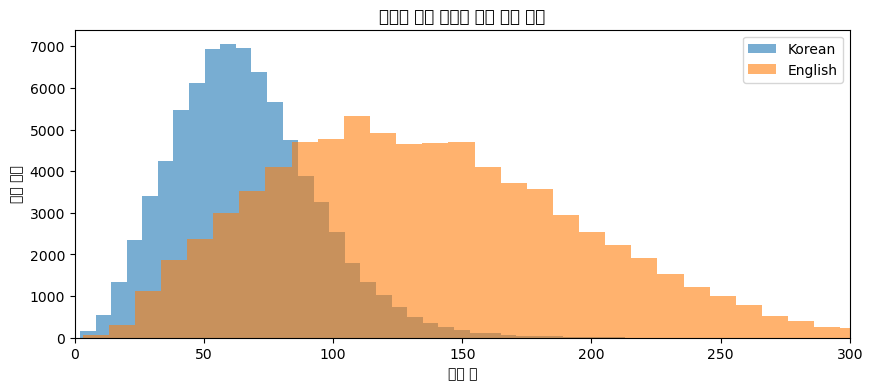

In [7]:
# 한국어 문장 길이를 모두 계산
ko_char_lengths = [len(ko) for ko, _ in train_pairs]
# 영어 문장 길이를 모두 계산
en_char_lengths = [len(en) for _, en in train_pairs]

# 결과 출력
print('한국어 문자 길이 분위수:', np.percentile(ko_char_lengths, [50, 75, 90, 95, 99]))
print('영어 문자 길이 분위수  :', np.percentile(en_char_lengths, [50, 75, 90, 95, 99]))

# 그래프
plt.figure(figsize=(10, 4))
# 한국어 문장 길이 분포를 그린다
plt.hist(ko_char_lengths, bins=60, alpha=0.6, label='Korean')
# 영어 문장 길이 분포도 같이 그린다
plt.hist(en_char_lengths, bins=60, alpha=0.6, label='English')
plt.xlim(0, 300)
plt.xlabel('문자 수')
plt.ylabel('문장 개수')
plt.title('정제된 학습 문장의 문자 길이 분포')
plt.legend()
plt.show()


## 4. SentencePiece 토크나이저 학습

SentencePiece는 문장을 단어보다 작은 서브워드 조각으로 나눈다  

이제 SentencePiece로 한국어와 영어 문장을 토큰화한다  

처음 보는 단어도 여러 조각으로 분해할 수 있어 한국어의 다양한 활용형을 다루는 데 유리하다  

토크나이저는 dev/test 데이터가 train에 들어가지 않게 유의 한다  

토크나이저가 계속 멈춰서 토크나이저 학습 문장 개수를 줄였더니 잘 돌아간다  

In [8]:
import os
import time
import random
from pathlib import Path

import sentencepiece as spm


# 패딩 토큰 번호
PAD_ID = 0   
# 문장 시작 토큰 번호
BOS_ID = 1   
# 문장 끝 토큰 번호
EOS_ID = 2    
# 모르는 단어 토큰 번호
UNK_ID = 3    


# 토크나이저 학습에 사용할 문장 개수
TOKENIZER_TRAIN_SIZE = 30_000

# 한국어 토크나이저가 사용할 단어 조각 개수
SRC_VOCAB_SIZE = 8_000
# 영어 토크나이저가 사용할 단어 조각 개수
TGT_VOCAB_SIZE = 8_000

# SentencePiece가 사용할 CPU 스레드 수
CPU_THREADS = min(4, os.cpu_count() or 1)

# 토크나이저용 문장을 같은 방식으로 뽑기 위한 시드
TOKENIZER_SEED = 42

# SentencePiece가 읽을 말뭉치 파일을 만드는 함수
def write_corpus(sentences, path):
    # 저장 경로를 Path 객체로 바꾼다
    path = Path(path)

    # 상위 폴더가 없으면 만든다
    path.parent.mkdir(parents=True, exist_ok=True)

    # 말뭉치 파일을 쓰기 모드로 연다
    with open(path, "w", encoding="utf-8") as file:
        # 문장을 하나씩 파일에 기록
        for sentence in sentences:
            # 한 줄에 한 문장씩 저장
            file.write(sentence.strip() + "\n")


# 전체 문장 중 토크나이저 학습에 쓸 문장만 고르는 함수
def select_tokenizer_sentences(sentences, sample_size, seed=42):
    # 전체 문장이 목표 개수보다 적은지 확인
    if len(sentences) <= sample_size:
        # 결과 반환
        return list(sentences)

    # 따로 사용할 랜덤 생성기 준비
    random_generator = random.Random(seed)

    # 전체 구간에서 겹치지 않게 문장 번호를 뽑는다
    selected_indexes = random_generator.sample(
        range(len(sentences)),
        sample_size,
    )

    # 결과 반환
    return [
        sentences[index]
        for index in selected_indexes
    ]


# SentencePiece BPE 토크나이저를 학습하거나 불러오는 함수
def train_sentencepiece(
    sentences,
    model_prefix,
    vocab_size,
    language_name,
):
    # 모델 접두사를 Path 객체로 바꾼다
    model_prefix = Path(model_prefix)

    corpus_path = Path(
        str(model_prefix) + "_corpus.txt"
    )

    model_path = Path(
        str(model_prefix) + ".model"
    )

    vocab_path = Path(
        str(model_prefix) + ".vocab"
    )

    # 토크나이저 저장 폴더가 없으면 만든다
    model_prefix.parent.mkdir(
        parents=True,
        exist_ok=True,
    )

    # 결과 출력
    print("\n" + "=" * 65)
    print(f"[{language_name} 토크나이저]")
    print(f"학습 문장 수      : {len(sentences):,}")
    print(f"Vocabulary 크기  : {vocab_size:,}")
    print(f"CPU 스레드 수     : {CPU_THREADS}")
    print(f"모델 저장 경로    : {model_path}")

    # 기존 토크나이저 모델이 있는지 확인
    if model_path.exists():
        # 결과 출력
        print(f"기존 토크나이저 사용: {model_path.name}")

        # 기존 SentencePiece 모델을 불러온다
        tokenizer = spm.SentencePieceProcessor(
            model_file=str(model_path)
        )

        # 결과 출력
        print(
            f"불러온 vocabulary 크기: "
            f"{tokenizer.get_piece_size():,}"
        )

        # 결과 반환
        return tokenizer

    # 토크나이저 학습 시간을 재기 시작
    start_time = time.time()

    # 결과 출력
    print("1단계: 말뭉치 파일 저장 중...")
    # 학습 문장을 말뭉치 파일로 저장
    write_corpus(sentences, corpus_path)

    corpus_size_mb = (
        corpus_path.stat().st_size
        / 1024
        / 1024
    )

    # 결과 출력
    print(
        f"말뭉치 저장 완료: "
        f"{corpus_size_mb:.2f} MB"
    )

    # 결과 출력
    print("2단계: SentencePiece BPE 학습 중...")

    # SentencePiece BPE 토크나이저 학습 시작
    spm.SentencePieceTrainer.train(
        input=str(corpus_path),

        model_prefix=str(model_prefix),

        vocab_size=vocab_size,

        model_type="bpe",

        character_coverage=1.0,

        pad_id=PAD_ID,
        bos_id=BOS_ID,
        eos_id=EOS_ID,
        unk_id=UNK_ID,

        hard_vocab_limit=False,

        shuffle_input_sentence=True,

        num_threads=CPU_THREADS,

        max_sentence_length=2048,

        minloglevel=1,
    )

    # 토크나이저 학습에 걸린 시간 계산
    elapsed = time.time() - start_time

    # 결과 출력
    print("3단계: 토크나이저 학습 완료")
    print(f"소요 시간: {elapsed:.1f}초")
    print(f"모델 생성: {model_path.exists()}")
    print(f"Vocab 생성: {vocab_path.exists()}")

    # 학습 후 모델 파일이 생겼는지 확인
    if not model_path.exists():
        # 문제가 있으면 이유를 보여주고 멈춘다
        raise FileNotFoundError(
            f"토크나이저 모델이 생성되지 않았습니다: {model_path}"
        )

    # 학습한 토크나이저를 불러와 반환
    return spm.SentencePieceProcessor(
        model_file=str(model_path)
    )


# 전체 학습 데이터에서 한국어 문장만 꺼낸다
all_ko_train_sentences = [
    ko for ko, _ in train_pairs
]

# 전체 학습 데이터에서 영어 문장만 꺼낸다
all_en_train_sentences = [
    en for _, en in train_pairs
]

# 결과 출력
print("전체 한국어 문장 수:", f"{len(all_ko_train_sentences):,}")
print("전체 영어 문장 수  :", f"{len(all_en_train_sentences):,}")


# 한국어 토크나이저 학습에 쓸 문장만 고른다
ko_tokenizer_sentences = select_tokenizer_sentences(
    all_ko_train_sentences,
    TOKENIZER_TRAIN_SIZE,
    TOKENIZER_SEED,
)

# 영어 토크나이저 학습에 쓸 문장만 고른다
en_tokenizer_sentences = select_tokenizer_sentences(
    all_en_train_sentences,
    TOKENIZER_TRAIN_SIZE,
    TOKENIZER_SEED,
)

# 결과 출력
print(
    "토크나이저용 한국어 문장 수:",
    f"{len(ko_tokenizer_sentences):,}",
)
print(
    "토크나이저용 영어 문장 수  :",
    f"{len(en_tokenizer_sentences):,}",
)

# 한국어 SentencePiece 토크나이저 생성
ko_tokenizer = train_sentencepiece(
    sentences=ko_tokenizer_sentences,
    model_prefix=TOKENIZER_DIR / "ko_spm",
    vocab_size=SRC_VOCAB_SIZE,
    language_name="한국어",
)

# 영어 SentencePiece 토크나이저 생성
en_tokenizer = train_sentencepiece(
    sentences=en_tokenizer_sentences,
    model_prefix=TOKENIZER_DIR / "en_spm",
    vocab_size=TGT_VOCAB_SIZE,
    language_name="영어",
)


# 한국어 토크나이저가 사용할 단어 조각 개수
SRC_VOCAB_SIZE = ko_tokenizer.get_piece_size()
# 영어 토크나이저가 사용할 단어 조각 개수
TGT_VOCAB_SIZE = en_tokenizer.get_piece_size()

# 결과 출력
print("\n" + "=" * 65)
print("토크나이저 준비 완료")
print("한국어 vocabulary 크기:", SRC_VOCAB_SIZE)
print("영어 vocabulary 크기  :", TGT_VOCAB_SIZE)

# 한국어 토큰화가 잘 되는지 볼 예시 문장
sample_ko = "인공지능은 새로운 가능성을 열어 준다."
# 영어 토큰화가 잘 되는지 볼 예시 문장
sample_en = "artificial intelligence opens new possibilities."

# 결과 출력
print("\n[한국어 토큰화]")
print(
    "pieces:",
    ko_tokenizer.encode(
        sample_ko,
        out_type=str,
    ),
)
print(
    "ids   :",
    ko_tokenizer.encode(
        sample_ko,
        out_type=int,
    ),
)
print("\n[영어 토큰화]")
print(
    "pieces:",
    en_tokenizer.encode(
        sample_en,
        out_type=str,
    ),
)
print(
    "ids   :",
    en_tokenizer.encode(
        sample_en,
        out_type=int,
    ),
)


전체 한국어 문장 수: 77,661
전체 영어 문장 수  : 77,661
토크나이저용 한국어 문장 수: 30,000
토크나이저용 영어 문장 수  : 30,000

[한국어 토크나이저]
학습 문장 수      : 30,000
Vocabulary 크기  : 8,000
CPU 스레드 수     : 4
모델 저장 경로    : /home/jovyan/work/ko_en_transformer/tokenizer/ko_spm.model
기존 토크나이저 사용: ko_spm.model
불러온 vocabulary 크기: 16,000

[영어 토크나이저]
학습 문장 수      : 30,000
Vocabulary 크기  : 8,000
CPU 스레드 수     : 4
모델 저장 경로    : /home/jovyan/work/ko_en_transformer/tokenizer/en_spm.model
기존 토크나이저 사용: en_spm.model
불러온 vocabulary 크기: 8,000

토크나이저 준비 완료
한국어 vocabulary 크기: 16000
영어 vocabulary 크기  : 8000

[한국어 토큰화]
pieces: ['▁인공', '지', '능', '은', '▁새로운', '▁가능성을', '▁열어', '▁준다', '.']
ids   : [5177, 13840, 14182, 13841, 534, 3323, 6108, 12584, 13835]

[영어 토큰화]
pieces: ['▁art', 'ific', 'ial', '▁intelligence', '▁op', 'ens', '▁new', '▁poss', 'ib', 'ilities', '.']
ids   : [1871, 1005, 147, 2179, 422, 451, 202, 1045, 314, 3103, 7922]


## 5. 토큰 ID 변환, 길이 필터링, DataLoader

각 문장은 [BOS] + SentencePiece ID들 + [EOS] 형태로 바뀐다  

MAX_LEN을 넘는 문장쌍은 중간을 억지로 자르지 않고 제외한다  

미니배치마다 가장 긴 문장까지만 Padding하는 동적 Padding을 사용한다  

짧은 문장까지 길이 64로 가득 채우지 않으므로 메모리를 아낄 수 있다  

In [9]:
# 문장을 숫자 토큰으로 바꾸는 함수
def encode_sentence(tokenizer, sentence):
    # SentencePiece로 문장을 숫자 토큰으로 바꾼다
    token_ids = tokenizer.encode(sentence, out_type=int)
    # 앞에는 BOS, 뒤에는 EOS를 붙여 반환
    return [BOS_ID] + token_ids + [EOS_ID]


# 한국어 영어 문장쌍을 토큰 번호로 바꾸는 함수
def encode_pairs(pairs, max_len):
    # 토큰화한 문장쌍을 담을 리스트
    encoded = []
    # 길이 때문에 제거된 문장 수
    removed = 0

    # 한국어 영어 문장쌍을 하나씩 토큰화
    for ko, en in tqdm(pairs, desc='문장 토큰화'):
        # 한국어 문장을 토큰 번호로 변환
        src_ids = encode_sentence(ko_tokenizer, ko)
        # 영어 문장을 토큰 번호로 변환
        tgt_ids = encode_sentence(en_tokenizer, en)

        # 두 문장이 최대 길이 안에 들어오는지 확인
        if len(src_ids) <= max_len and len(tgt_ids) <= max_len:
            # 길이가 알맞으면 학습 데이터에 추가
            encoded.append((src_ids, tgt_ids))
        else:
            # 너무 긴 문장은 제거 개수 증가
            removed += 1

    # 결과 반환
    return encoded, removed


train_encoded, train_removed = encode_pairs(train_pairs, MAX_LEN)
valid_encoded, valid_removed = encode_pairs(valid_pairs, MAX_LEN)
test_encoded, test_removed = encode_pairs(test_pairs, MAX_LEN)

# 결과 출력
print(f'train 사용/제거: {len(train_encoded):,} / {train_removed:,}')
print(f'valid 사용/제거: {len(valid_encoded):,} / {valid_removed:,}')
print(f'test  사용/제거: {len(test_encoded):,} / {test_removed:,}')

# 길이 필터링 후 학습 데이터가 남았는지 확인
if not train_encoded:
    # 문제가 있으면 이유를 보여주고 멈춘다
    raise RuntimeError('길이 필터링 후 학습 데이터가 없습니다. MAX_LEN을 늘려 주세요.')


문장 토큰화:   0%|          | 0/77661 [00:00<?, ?it/s]

문장 토큰화:   0%|          | 0/990 [00:00<?, ?it/s]

문장 토큰화:   0%|          | 0/1968 [00:00<?, ?it/s]

train 사용/제거: 75,489 / 2,172
valid 사용/제거: 958 / 32
test  사용/제거: 1,893 / 75


Dataset과 DataLoader를 구성한다

In [10]:
# 한국어 영어 문장쌍을 보관하는 Dataset 클래스
class TranslationDataset(Dataset):
    def __init__(self, encoded_pairs):
        # 토큰화한 문장쌍을 클래스 안에 보관
        self.encoded_pairs = encoded_pairs

    def __len__(self):
        # 전체 데이터 개수 반환
        return len(self.encoded_pairs)

    def __getitem__(self, index):
        # index번째 한국어 영어 문장쌍을 꺼낸다
        src_ids, tgt_ids = self.encoded_pairs[index]

        # 결과 반환
        return (
            torch.tensor(src_ids, dtype=torch.long),
            torch.tensor(tgt_ids, dtype=torch.long),
        )


# 길이가 다른 문장에 PAD를 채우는 함수
def pad_1d_sequences(sequences, pad_id):
    # 현재 배치의 문장 개수
    batch_size = len(sequences)
    # 배치 안에서 가장 긴 문장 길이 계산
    max_length = max(sequence.size(0) for sequence in sequences)

    # PAD로 가득 찬 빈 배치 텐서 생성
    padded = torch.full(
        (batch_size, max_length),
        fill_value=pad_id,
        dtype=torch.long,
    )

    # 문장을 하나씩 배치에 넣는다
    for row, sequence in enumerate(sequences):
        # 실제 토큰을 앞쪽에 채운다
        padded[row, :sequence.size(0)] = sequence

    # 결과 반환
    return padded


# 여러 문장쌍을 한 배치로 묶는 함수
def collate_translation_batch(batch):
    # 한국어와 영어 배치를 따로 나눈다
    src_batch, tgt_batch = zip(*batch)

    # 결과 반환
    return (
        pad_1d_sequences(src_batch, PAD_ID),
        pad_1d_sequences(tgt_batch, PAD_ID),
    )


# 데이터셋 생성
train_dataset = TranslationDataset(train_encoded)
valid_dataset = TranslationDataset(valid_encoded)
test_dataset = TranslationDataset(test_encoded)

# 학습 데이터 로더
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_translation_batch,
    num_workers=0,
    pin_memory=(DEVICE.type == 'cuda'),
)

# 검증 데이터 로더
valid_loader = DataLoader(
    valid_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_translation_batch,
    num_workers=0,
    pin_memory=(DEVICE.type == 'cuda'),
)

# 테스트 데이터 로더
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_translation_batch,
    num_workers=0,
    pin_memory=(DEVICE.type == 'cuda'),
)

sample_src, sample_tgt = next(iter(train_loader))

# 결과 출력
print('Encoder 입력 모양:', sample_src.shape)
print('Decoder 정답 모양:', sample_tgt.shape)
print('첫 한국어 토큰 ID:', sample_src[0, :20].tolist())
print('첫 영어 토큰 ID  :', sample_tgt[0, :20].tolist())


Encoder 입력 모양: torch.Size([64, 56])
Decoder 정답 모양: torch.Size([64, 61])
첫 한국어 토큰 ID: [1, 5, 2605, 7111, 225, 13922, 610, 13973, 729, 20, 13888, 10, 738, 13973, 108, 133, 549, 4976, 4, 17]
첫 영어 토큰 ID  : [1, 86, 520, 605, 320, 1020, 1412, 16, 152, 143, 1584, 7924, 201, 16, 45, 428, 867, 833, 13, 57]


Positional Encoding과 Multi-Head Attention을 직접 만든다

In [11]:
# 문장 속 토큰 위치 정보를 더하는 클래스 정의
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len, dropout):
        super().__init__()
        self.dropout = nn.Dropout(dropout)

        # 0부터 최대 길이까지 위치 번호 생성
        position = torch.arange(max_len, dtype=torch.float32).unsqueeze(1)
        # sin cos 주파수 계산
        div_term = torch.exp(
            torch.arange(0, d_model, 2, dtype=torch.float32)
            * (-math.log(10_000.0) / d_model)
        )

        # 위치 인코딩을 담을 빈 행렬
        table = torch.zeros(max_len, d_model)
        # 짝수 차원에는 sin 값을 넣는다
        table[:, 0::2] = torch.sin(position * div_term)
        # 홀수 차원에는 cos 값을 넣는다
        table[:, 1::2] = torch.cos(position * div_term)

        # 학습값은 아니지만 모델과 함께 저장되게 한다
        self.register_buffer('table', table.unsqueeze(0))

    # 모델이 한 번 앞으로 계산하는 함수
    def forward(self, x):
        # 현재 문장 길이 확인
        sequence_length = x.size(1)
        # 입력 임베딩에 위치 정보를 더한다
        x = x + self.table[:, :sequence_length]
        # 결과 반환
        return self.dropout(x)


# 여러 관점으로 단어 관계를 보는 Multi-Head Attention 클래스
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, n_heads, dropout):
        super().__init__()

        # 임베딩 차원을 Head 수로 나눌 수 있는지 확인
        if d_model % n_heads != 0:
            # 문제가 있으면 이유를 보여주고 멈춘다
            raise ValueError('d_model은 n_heads로 나누어떨어져야 합니다.')

        self.d_model = d_model
        self.n_heads = n_heads
        # Head 하나가 맡을 차원 계산
        self.head_dim = d_model // n_heads

        # Query를 만드는 Linear 층
        self.q_projection = nn.Linear(d_model, d_model)
        # Key를 만드는 Linear 층
        self.k_projection = nn.Linear(d_model, d_model)
        # Value를 만드는 Linear 층
        self.v_projection = nn.Linear(d_model, d_model)
        # 여러 Head 결과를 다시 섞는 Linear 층
        self.output_projection = nn.Linear(d_model, d_model)
        self.attention_dropout = nn.Dropout(dropout)

    # 임베딩을 여러 Attention 머리로 나누는 함수
    def split_heads(self, x):
        batch_size, sequence_length, _ = x.shape
        x = x.view(batch_size, sequence_length, self.n_heads, self.head_dim)
        # 결과 반환
        return x.transpose(1, 2)

    # 여러 Attention 머리를 다시 하나로 합치는 함수
    def combine_heads(self, x):
        batch_size, _, sequence_length, _ = x.shape
        x = x.transpose(1, 2).contiguous()
        # 결과 반환
        return x.view(batch_size, sequence_length, self.d_model)

    # 모델이 한 번 앞으로 계산하는 함수
    def forward(self, query, key, value, mask=None):
        # 입력을 Query로 바꾸고 Head별로 나눈다
        q = self.split_heads(self.q_projection(query))
        # 입력을 Key로 바꾸고 Head별로 나눈다
        k = self.split_heads(self.k_projection(key))
        # 입력을 Value로 바꾸고 Head별로 나눈다
        v = self.split_heads(self.v_projection(value))

        # Query와 Key가 얼마나 비슷한지 점수 계산
        scores = torch.matmul(q, k.transpose(-2, -1))
        # 점수가 너무 커지지 않게 크기를 조절
        scores = scores / math.sqrt(self.head_dim)

        # 가려야 할 위치가 있는지 확인
        if mask is not None:
            # 마스크 위치 점수를 아주 작게 만든다
            scores = scores.masked_fill(mask, torch.finfo(scores.dtype).min)

        # 점수를 Attention 확률로 바꾼다
        attention_weights = torch.softmax(scores, dim=-1)
        attention_weights = self.attention_dropout(attention_weights)

        # Attention 확률만큼 Value 정보를 모은다
        attention_output = torch.matmul(attention_weights, v)
        attention_output = self.combine_heads(attention_output)
        attention_output = self.output_projection(attention_output)

        # 결과 반환
        return attention_output, attention_weights


In [12]:
# Attention 결과를 토큰마다 다시 가공하는 Feed Forward 클래스
class PositionwiseFeedForward(nn.Module):
    def __init__(self, d_model, d_ff, dropout):
        super().__init__()
        # 임베딩 차원을 Feed Forward 안쪽으로 넓힌다
        self.linear_1 = nn.Linear(d_model, d_ff)
        # 넓힌 차원을 다시 원래 크기로 줄인다
        self.linear_2 = nn.Linear(d_ff, d_model)
        self.dropout = nn.Dropout(dropout)

    # 모델이 한 번 앞으로 계산하는 함수
    def forward(self, x):
        x = self.linear_1(x)
        # GELU 활성화 함수 적용
        x = F.gelu(x)
        x = self.dropout(x)
        # 결과 반환
        return self.linear_2(x)


# Encoder 한 층을 만드는 클래스
class EncoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout):
        super().__init__()
        # Encoder가 자기 문장 안의 단어 관계를 본다
        self.self_attention = MultiHeadAttention(d_model, n_heads, dropout)
        self.feed_forward = PositionwiseFeedForward(d_model, d_ff, dropout)
        self.norm_1 = nn.LayerNorm(d_model)
        self.norm_2 = nn.LayerNorm(d_model)
        self.dropout_1 = nn.Dropout(dropout)
        self.dropout_2 = nn.Dropout(dropout)

    # 모델이 한 번 앞으로 계산하는 함수
    def forward(self, x, src_mask):
        # Attention 전에 값을 정규화
        normalized = self.norm_1(x)
        attention_output, attention_weights = self.self_attention(
            normalized, normalized, normalized, src_mask
        )
        # 원래 정보와 Attention 결과를 더한다
        x = x + self.dropout_1(attention_output)

        # Feed Forward 전에 다시 정규화
        normalized = self.norm_2(x)
        x = x + self.dropout_2(self.feed_forward(normalized))

        # 결과 반환
        return x, attention_weights


# Decoder 한 층을 만드는 클래스
class DecoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout):
        super().__init__()
        # Encoder가 자기 문장 안의 단어 관계를 본다
        self.self_attention = MultiHeadAttention(d_model, n_heads, dropout)
        # Decoder가 Encoder의 한국어 정보를 본다
        self.cross_attention = MultiHeadAttention(d_model, n_heads, dropout)
        self.feed_forward = PositionwiseFeedForward(d_model, d_ff, dropout)
        self.norm_1 = nn.LayerNorm(d_model)
        self.norm_2 = nn.LayerNorm(d_model)
        self.norm_3 = nn.LayerNorm(d_model)
        self.dropout_1 = nn.Dropout(dropout)
        self.dropout_2 = nn.Dropout(dropout)
        self.dropout_3 = nn.Dropout(dropout)

    # 모델이 한 번 앞으로 계산하는 함수
    def forward(self, x, encoder_output, tgt_mask, cross_mask):
        # Attention 전에 값을 정규화
        normalized = self.norm_1(x)
        self_output, self_weights = self.self_attention(
            normalized, normalized, normalized, tgt_mask
        )
        x = x + self.dropout_1(self_output)

        # Cross-Attention 전에 다시 정규화
        normalized = self.norm_2(x)
        cross_output, cross_weights = self.cross_attention(
            normalized, encoder_output, encoder_output, cross_mask
        )
        x = x + self.dropout_2(cross_output)

        # Feed Forward 전에 다시 정규화
        normalized = self.norm_3(x)
        x = x + self.dropout_3(self.feed_forward(normalized))

        # 결과 반환
        return x, self_weights, cross_weights


Encoder Decoder를 쌓고 Attention 마스크를 만든다

In [13]:
# Encoder Layer를 여러 층 쌓는 클래스
class Encoder(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff, dropout):
        super().__init__()
        self.layers = nn.ModuleList([
            EncoderLayer(d_model, n_heads, d_ff, dropout)
            for _ in range(n_layers)
        ])
        self.final_norm = nn.LayerNorm(d_model)

    # 모델이 한 번 앞으로 계산하는 함수
    def forward(self, x, src_mask):
        # 층별 Attention 결과를 담을 리스트
        attention_maps = []

        # Layer를 하나씩 통과
        for layer in self.layers:
            x, attention_weights = layer(x, src_mask)
            attention_maps.append(attention_weights)

        # 결과 반환
        return self.final_norm(x), attention_maps


# Decoder Layer를 여러 층 쌓는 클래스
class Decoder(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff, dropout):
        super().__init__()
        self.layers = nn.ModuleList([
            DecoderLayer(d_model, n_heads, d_ff, dropout)
            for _ in range(n_layers)
        ])
        self.final_norm = nn.LayerNorm(d_model)

    # 모델이 한 번 앞으로 계산하는 함수
    def forward(self, x, encoder_output, tgt_mask, cross_mask):
        # 층별 Decoder Self-Attention을 담을 리스트
        self_attention_maps = []
        # 층별 Cross-Attention을 담을 리스트
        cross_attention_maps = []

        # Layer를 하나씩 통과
        for layer in self.layers:
            x, self_weights, cross_weights = layer(
                x, encoder_output, tgt_mask, cross_mask
            )
            self_attention_maps.append(self_weights)
            cross_attention_maps.append(cross_weights)

        # 결과 반환
        return self.final_norm(x), self_attention_maps, cross_attention_maps


# PAD 토큰을 못 보게 하는 마스크 생성 함수
def create_padding_mask(sequence, pad_id=PAD_ID):
    # 결과 반환
    return (sequence == pad_id).unsqueeze(1).unsqueeze(2)


# 미래 토큰을 못 보게 하는 마스크 생성 함수
def create_causal_mask(length, device):
    # 결과 반환
    return torch.triu(
        torch.ones(length, length, dtype=torch.bool, device=device),
        diagonal=1,
    ).unsqueeze(0).unsqueeze(0)


# Encoder와 Decoder에서 사용할 마스크를 한 번에 만드는 함수
def create_attention_masks(src, tgt):
    # Encoder에서 한국어 PAD 위치를 가린다
    src_mask = create_padding_mask(src)
    # Decoder에서 PAD와 미래 토큰을 함께 가린다
    tgt_mask = create_padding_mask(tgt) | create_causal_mask(tgt.size(1), tgt.device)
    # Cross-Attention에서도 한국어 PAD 위치를 가린다
    cross_mask = src_mask
    # 결과 반환
    return src_mask, tgt_mask, cross_mask


마스크가 반대로 만들어지지 않았는지 그림으로 확인한다

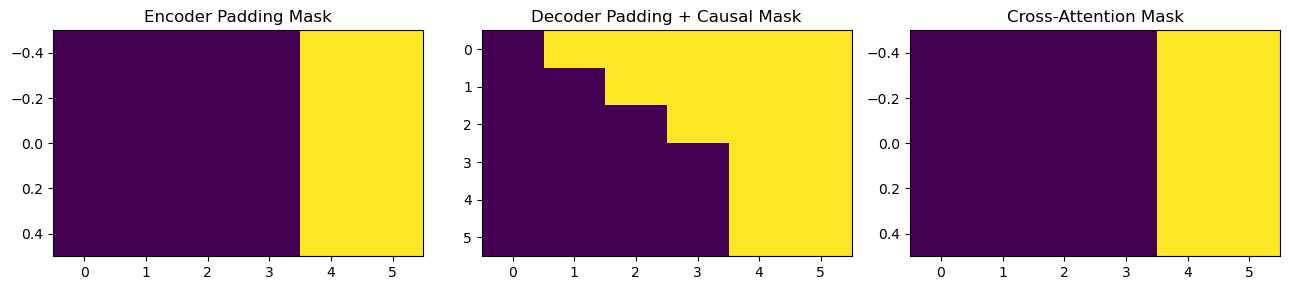

In [14]:
# 마스크 방향을 확인할 작은 예시 문장 생성
mask_example = torch.tensor([[BOS_ID, 10, 20, EOS_ID, PAD_ID, PAD_ID]])
src_mask_example, tgt_mask_example, cross_mask_example = create_attention_masks(
    mask_example, mask_example
)

# 세 가지 마스크를 나란히 볼 그래프 준비
fig, axes = plt.subplots(1, 3, figsize=(13, 3))
axes[0].imshow(src_mask_example[0, 0].cpu(), aspect='auto')
axes[0].set_title('Encoder Padding Mask')
axes[1].imshow(tgt_mask_example[0, 0].cpu(), aspect='auto')
axes[1].set_title('Decoder Padding + Causal Mask')
axes[2].imshow(cross_mask_example[0, 0].cpu(), aspect='auto')
axes[2].set_title('Cross-Attention Mask')
plt.tight_layout()
plt.show()


지금까지 만든 코드를 하나의 Transformer 번역기로 연결한다

In [15]:
# Attention 기반 한국어 영어 번역 모델
class Transformer(nn.Module):
    def __init__(
        self,
        src_vocab_size,
        tgt_vocab_size,
        max_len,
        d_model,
        n_layers,
        n_heads,
        d_ff,
        dropout,
    ):
        super().__init__()
        self.d_model = d_model

        # 한국어 토큰 임베딩
        self.src_embedding = nn.Embedding(src_vocab_size, d_model, padding_idx=PAD_ID)
        # 영어 토큰 임베딩
        self.tgt_embedding = nn.Embedding(tgt_vocab_size, d_model, padding_idx=PAD_ID)
        self.src_position = PositionalEncoding(d_model, max_len, dropout)
        self.tgt_position = PositionalEncoding(d_model, max_len, dropout)
        # 한국어 문장을 이해할 Encoder 생성
        self.encoder = Encoder(n_layers, d_model, n_heads, d_ff, dropout)
        # 영어 문장을 만들 Decoder 생성
        self.decoder = Decoder(n_layers, d_model, n_heads, d_ff, dropout)
        # Decoder 출력을 영어 vocab 점수로 바꾼다
        self.output_layer = nn.Linear(d_model, tgt_vocab_size, bias=False)

        # 영어 입력 표와 출력 표를 같이 사용
        self.output_layer.weight = self.tgt_embedding.weight
        # 모델 가중치 초기화
        self.reset_parameters()

    # 모델 가중치를 처음 학습하기 좋은 값으로 초기화하는 함수
    def reset_parameters(self):
        # 모델 파라미터를 하나씩 확인
        for parameter in self.parameters():
            if parameter.dim() > 1:
                # 행렬 가중치를 Xavier 방식으로 초기화
                nn.init.xavier_uniform_(parameter)

        # PAD 행은 학습에 쓰지 않으므로 gradient 없이 0으로 고정
        with torch.no_grad():
            self.src_embedding.weight[PAD_ID].fill_(0)
            self.tgt_embedding.weight[PAD_ID].fill_(0)

    # 한국어 문장을 Encoder로 보내는 함수
    def encode(self, src, src_mask):
        x = self.src_embedding(src) * math.sqrt(self.d_model)
        x = self.src_position(x)
        # 결과 반환
        return self.encoder(x, src_mask)

    # Encoder 정보를 참고해서 영어 문장을 만드는 함수
    def decode(self, tgt, encoder_output, tgt_mask, cross_mask):
        x = self.tgt_embedding(tgt) * math.sqrt(self.d_model)
        x = self.tgt_position(x)
        # 결과 반환
        return self.decoder(x, encoder_output, tgt_mask, cross_mask)

    # 모델이 한 번 앞으로 계산하는 함수
    def forward(self, src, tgt):
        src_mask, tgt_mask, cross_mask = create_attention_masks(src, tgt)
        # 한국어 입력을 Encoder에 전달
        encoder_output, encoder_attentions = self.encode(src, src_mask)
        # Encoder 정보를 참고해 Decoder 계산
        decoder_output, decoder_attentions, cross_attentions = self.decode(
            tgt, encoder_output, tgt_mask, cross_mask
        )
        # Decoder 결과를 영어 단어 점수로 변환
        logits = self.output_layer(decoder_output)

        # 결과 반환
        return logits, encoder_attentions, decoder_attentions, cross_attentions


## 7. 모델 생성과 Forward Pass 점검  

긴 학습 전에 미니배치 하나를 통과시켜 텐서 모양과 Attention 출력이 정상인지 확인한다  

모델에 값을 전달해주고 학습 스탠바이  

In [16]:
# 설정한 값으로 Transformer 번역 모델 생성
model = Transformer(
    src_vocab_size=SRC_VOCAB_SIZE,
    tgt_vocab_size=TGT_VOCAB_SIZE,
    max_len=MAX_LEN,
    d_model=D_MODEL,
    n_layers=N_LAYERS,
    n_heads=N_HEADS,
    d_ff=D_FF,
    dropout=DROPOUT,
).to(DEVICE)


# 학습할 수 있는 파라미터 개수를 세는 함수
def count_trainable_parameters(model):
    # 결과 반환
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


# 학습 가능한 파라미터 수 확인
print(f'학습 가능한 파라미터 수: {count_trainable_parameters(model):,}')

# 배치에서 한국어 문장 두 개만 꺼낸다
smoke_src = sample_src[:2].to(DEVICE)
# 영어 정답에서 마지막 토큰을 빼 Decoder 입력 생성
smoke_tgt_input = sample_tgt[:2, :-1].to(DEVICE)

# gradient 없이 가볍게 모델 모양만 확인
with torch.no_grad():
    smoke_logits, enc_attn, dec_attn, cross_attn = model(smoke_src, smoke_tgt_input)

# 결과 출력
print('Logits 모양                 :', smoke_logits.shape)
# 결과 출력
print('Encoder layer 개수          :', len(enc_attn))
# 결과 출력
print('Decoder self-attention 개수 :', len(dec_attn))
# 결과 출력
print('Cross-attention 개수        :', len(cross_attn))
# 결과 출력
print('마지막 Cross-Attention 모양 :', cross_attn[-1].shape)

# 출력 배치 크기가 입력과 같은지 확인
assert smoke_logits.size(0) == smoke_src.size(0)
# 마지막 차원이 영어 vocab 크기인지 확인
assert smoke_logits.size(-1) == TGT_VOCAB_SIZE
# 결과 출력
print('\nForward Pass 점검 완료 ✅')


학습 가능한 파라미터 수: 11,674,624
Logits 모양                 : torch.Size([2, 60, 8000])
Encoder layer 개수          : 3
Decoder self-attention 개수 : 3
Cross-attention 개수        : 3
마지막 Cross-Attention 모양 : torch.Size([2, 8, 60, 56])

Forward Pass 점검 완료 ✅


## 8. Loss, Noam Learning Rate, 학습 함수 

In [17]:
# 손실 함수 생성, PAD는 무시하고 label smoothing을 넣는다
criterion = nn.CrossEntropyLoss(
    ignore_index=PAD_ID,
    label_smoothing=0.1,
)

# Adam 옵티마이저 생성
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4,
    betas=(0.9, 0.98),
    eps=1e-9,
)

# GPU에서 혼합 정밀도 학습을 사용할지 확인
USE_AMP = DEVICE.type == 'cuda'
# 작은 gradient가 사라지지 않도록 AMP scaler 준비
scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)


# Transformer 학습 단계에 맞춰 학습률을 계산하는 함수
def noam_learning_rate(step, d_model, warmup_steps):
    step = max(step, 1)
    # 결과 반환
    return d_model ** -0.5 * min(
        step ** -0.5,
        step * warmup_steps ** -1.5,
    )


# PAD를 빼고 토큰 정확도를 계산하는 함수
def calculate_token_accuracy(logits, targets):
    # 각 위치에서 점수가 가장 높은 토큰 선택
    predictions = logits.argmax(dim=-1)
    # PAD가 아닌 정답 위치만 표시
    valid_mask = targets != PAD_ID
    # 맞힌 토큰 개수 계산
    correct = ((predictions == targets) & valid_mask).sum().item()
    # PAD를 제외한 전체 토큰 개수 계산
    total = valid_mask.sum().item()
    # 결과 반환
    return correct, total


/tmp/ipykernel_1209/3937244956.py:18: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)


In [18]:
# 한 epoch 동안 학습하는 함수
def train_one_epoch(model, data_loader, optimizer, criterion, scaler, global_step):
    # 모델을 학습 모드로 바꾼다
    model.train()
    # 누적 손실
    total_loss_sum = 0.0
    # 맞힌 토큰 누적 개수
    total_correct = 0
    # PAD를 제외한 전체 토큰 수
    total_tokens = 0

    # 학습 진행바 준비
    progress_bar = tqdm(data_loader, desc='Train', leave=False)

    # 학습 배치를 하나씩 꺼낸다
    for src, tgt in progress_bar:
        # 한국어 입력을 장치로 보낸다
        src = src.to(DEVICE, non_blocking=True)
        # 영어 정답을 장치로 보낸다
        tgt = tgt.to(DEVICE, non_blocking=True)

        # Decoder 입력은 EOS 전까지
        tgt_input = tgt[:, :-1]
        # 정답은 BOS 다음부터
        tgt_output = tgt[:, 1:]

        # 이전 gradient를 지운다
        optimizer.zero_grad(set_to_none=True)
        # 전체 학습 step을 하나 증가
        global_step += 1

        # 현재 step에 맞는 학습률 계산
        learning_rate = noam_learning_rate(global_step, D_MODEL, WARMUP_STEPS)
        # 옵티마이저 설정을 하나씩 확인
        for group in optimizer.param_groups:
            # 옵티마이저에 새 학습률 적용
            group['lr'] = learning_rate

        # GPU에서는 혼합 정밀도로 계산
        with torch.cuda.amp.autocast(enabled=USE_AMP):
            # 모델 예측 실행
            logits, _, _, _ = model(src, tgt_input)
            # 예측과 정답의 차이로 loss 계산
            loss = criterion(
                logits.reshape(-1, TGT_VOCAB_SIZE),
                tgt_output.reshape(-1),
            )

        # 역전파로 gradient 계산
        scaler.scale(loss).backward()
        # gradient clipping 전에 원래 크기로 되돌린다
        scaler.unscale_(optimizer)
        # gradient 폭주 방지
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        # 모델 파라미터 업데이트
        scaler.step(optimizer)
        # 다음 step을 위해 scaler 갱신
        scaler.update()

        correct, token_count = calculate_token_accuracy(logits.detach(), tgt_output)
        total_loss_sum += loss.item() * token_count
        total_correct += correct
        total_tokens += token_count

        progress_bar.set_postfix(
            loss=f'{total_loss_sum / max(total_tokens, 1):.4f}',
            accuracy=f'{total_correct / max(total_tokens, 1):.4f}',
            lr=f'{learning_rate:.2e}',
        )

    # 결과 반환
    return (
        total_loss_sum / max(total_tokens, 1),
        total_correct / max(total_tokens, 1),
        global_step,
    )


# gradient 계산 없이 검증하는 함수
# 검증할 때는 gradient 계산이 필요 없으니 잠시 끈다
@torch.no_grad()
def evaluate_one_epoch(model, data_loader, criterion):
    # 모델을 평가 모드로 바꾼다
    model.eval()
    # 누적 손실
    total_loss_sum = 0.0
    # 맞힌 토큰 누적 개수
    total_correct = 0
    # PAD를 제외한 전체 토큰 수
    total_tokens = 0

    # 검증 배치를 하나씩 본다
    for src, tgt in tqdm(data_loader, desc='Valid', leave=False):
        # 한국어 입력을 장치로 보낸다
        src = src.to(DEVICE, non_blocking=True)
        # 영어 정답을 장치로 보낸다
        tgt = tgt.to(DEVICE, non_blocking=True)

        # Decoder 입력은 EOS 전까지
        tgt_input = tgt[:, :-1]
        # 정답은 BOS 다음부터
        tgt_output = tgt[:, 1:]

        # 모델 예측 실행
        logits, _, _, _ = model(src, tgt_input)
        # 예측과 정답의 차이로 loss 계산
        loss = criterion(
            logits.reshape(-1, TGT_VOCAB_SIZE),
            tgt_output.reshape(-1),
        )

        correct, token_count = calculate_token_accuracy(logits, tgt_output)
        total_loss_sum += loss.item() * token_count
        total_correct += correct
        total_tokens += token_count

    # 결과 반환
    return (
        total_loss_sum / max(total_tokens, 1),
        total_correct / max(total_tokens, 1),
    )


## 9. 모델 학습과 Early Stopping  

Validation Loss가 가장 낮을 때의 모델만 저장한다  

여러 epoch 동안 좋아지지 않으면 학습을 멈춰 과적합과 불필요한 계산을 줄인다  

이제 학습ㄱㄱ  

In [19]:
# 학습 결과를 저장할 딕셔너리
history = {
    'train_loss': [],
    'valid_loss': [],
    'train_accuracy': [],
    'valid_accuracy': [],
}

# 가장 좋은 validation loss
best_valid_loss = float('inf')
# 개선 없는 epoch 수를 0으로 시작
epochs_without_improvement = 0
# 전체 학습 step 수
global_step = 0
# 전체 학습 시간을 재기 시작
training_start = time.time()

# epoch 반복 시작
for epoch in range(1, EPOCHS + 1):
    epoch_start = time.time()

    # 한 epoch 학습 loss와 정확도 계산
    train_loss, train_accuracy, global_step = train_one_epoch(
        model, train_loader, optimizer, criterion, scaler, global_step
    )
    # validation loss와 정확도 계산
    valid_loss, valid_accuracy = evaluate_one_epoch(
        model, valid_loader, criterion
    )

    history['train_loss'].append(train_loss)
    history['valid_loss'].append(valid_loss)
    history['train_accuracy'].append(train_accuracy)
    history['valid_accuracy'].append(valid_accuracy)

    # 결과 출력
    print(
        f'Epoch {epoch:02d}/{EPOCHS} | '
        f'train loss={train_loss:.4f}, valid loss={valid_loss:.4f}, '
        f'train acc={train_accuracy:.4f}, valid acc={valid_accuracy:.4f}, '
        f'time={time.time() - epoch_start:.1f}s'
    )

    # validation loss가 좋아졌는지 확인
    if valid_loss < best_valid_loss:
        # 가장 좋은 validation loss 갱신
        best_valid_loss = valid_loss
        # 성능이 좋아졌으므로 기다린 횟수 초기화
        epochs_without_improvement = 0

        # 현재 best 모델 체크포인트 저장
        torch.save(
            {
                'model_state_dict': model.state_dict(),
                'model_config': {
                    'src_vocab_size': SRC_VOCAB_SIZE,
                    'tgt_vocab_size': TGT_VOCAB_SIZE,
                    'max_len': MAX_LEN,
                    'd_model': D_MODEL,
                    'n_layers': N_LAYERS,
                    'n_heads': N_HEADS,
                    'd_ff': D_FF,
                    'dropout': DROPOUT,
                },
                'best_valid_loss': best_valid_loss,
                'epoch': epoch,
            },
            MODEL_PATH,
        )
        # 결과 출력
        print(f'  ↳ 가장 좋은 모델 저장: {MODEL_PATH}')
    else:
        # 좋아지지 않았으므로 patience 카운트 증가
        epochs_without_improvement += 1
        # 결과 출력
        print(f'  ↳ 개선 없음: {epochs_without_improvement}/{PATIENCE}')

        # 기다린 횟수가 patience를 넘었는지 확인
        if epochs_without_improvement >= PATIENCE:
            # 결과 출력
            print('Early Stopping: Validation Loss가 더 이상 좋아지지 않았습니다.')
            # 조건을 채웠으니 반복 종료
            break

# 결과 출력
print(f'\n전체 학습 시간: {(time.time() - training_start) / 60:.1f}분')
# 결과 출력
print(f'최저 Validation Loss: {best_valid_loss:.4f}')


Train:   0%|          | 0/1180 [00:00<?, ?it/s]

/tmp/ipykernel_1209/941245433.py:40: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


Valid:   0%|          | 0/15 [00:00<?, ?it/s]

Epoch 01/12 | train loss=7.0933, valid loss=6.1248, train acc=0.1162, valid acc=0.1805, time=71.7s
  ↳ 가장 좋은 모델 저장: /home/jovyan/work/ko_en_transformer/model/best_ko_en_transformer.pt


Train:   0%|          | 0/1180 [00:00<?, ?it/s]

...

Valid:   0%|          | 0/15 [00:00<?, ?it/s]

Epoch 11/12 | train loss=4.1187, valid loss=4.4214, train acc=0.3921, valid acc=0.3700, time=71.3s
  ↳ 가장 좋은 모델 저장: /home/jovyan/work/ko_en_transformer/model/best_ko_en_transformer.pt


Train:   0%|          | 0/1180 [00:00<?, ?it/s]

Valid:   0%|          | 0/15 [00:00<?, ?it/s]

Epoch 12/12 | train loss=4.0625, valid loss=4.4086, train acc=0.4009, valid acc=0.3736, time=71.7s
  ↳ 가장 좋은 모델 저장: /home/jovyan/work/ko_en_transformer/model/best_ko_en_transformer.pt

전체 학습 시간: 14.4분
최저 Validation Loss: 4.4086


## 10. 학습 곡선과 최적 모델 불러오기  

학습이 끝났으니 그래프로 확인하고 best 모델을 불러온다  

/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 54617 (\N{HANGUL SYLLABLE HAG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49845 (\N{HANGUL SYLLABLE SEUB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


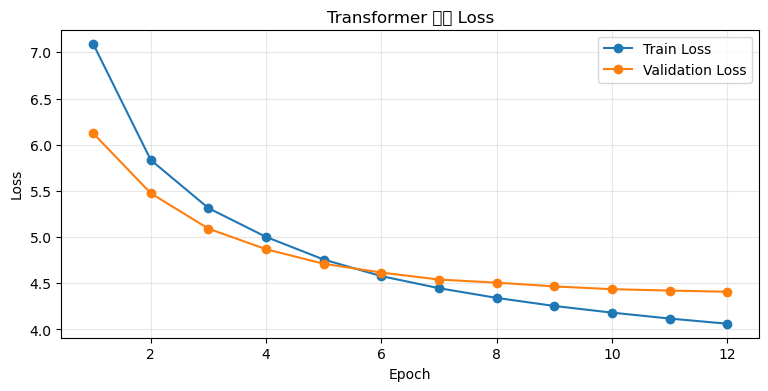

/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 47484 (\N{HANGUL SYLLABLE REUL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 50808 (\N{HANGUL SYLLABLE OE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 54620 (\N{HANGUL SYLLABLE HAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 53664 (\N{HANGUL SYLLABLE TO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/co

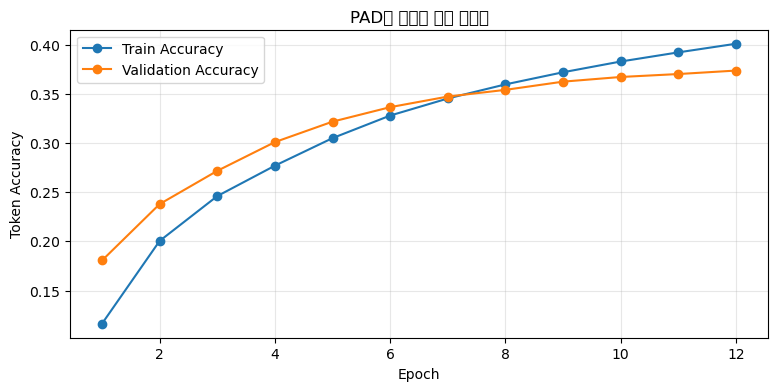

불러온 모델: epoch=12, valid loss=4.4086


In [20]:
# 학습한 epoch 번호를 만든다
epochs = range(1, len(history['train_loss']) + 1)

# 그래프

plt.figure(figsize=(9, 4))
# train loss 선을 그린다
plt.plot(epochs, history['train_loss'], marker='o', label='Train Loss')
# validation loss 선을 그린다
plt.plot(epochs, history['valid_loss'], marker='o', label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Transformer 학습 Loss')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(9, 4))
plt.plot(epochs, history['train_accuracy'], marker='o', label='Train Accuracy')
plt.plot(epochs, history['valid_accuracy'], marker='o', label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Token Accuracy')
plt.title('PAD를 제외한 토큰 정확도')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# 저장된 best 모델을 불러온다
checkpoint = torch.load(MODEL_PATH, map_location=DEVICE)
# 저장된 가중치를 모델에 적용
model.load_state_dict(checkpoint['model_state_dict'])
# 모델을 평가 모드로 바꾼다
model.eval()

# 결과 출력
print(
    f"불러온 모델: epoch={checkpoint['epoch']}, "
    f"valid loss={checkpoint['best_valid_loss']:.4f}"
)


## 11. 실제 번역과 평가 문장

실제 번역에는 정답 영어 문장이 없으므로 `<BOS>`에서 시작해 다음 토큰을 하나씩 생성한다  

`<EOS>` 가 나오면 번역을 종료  

In [21]:
# 번역할 한국어 문장을 Encoder 입력으로 바꾸는 함수
def prepare_source_sentence(sentence):
    # 입력 한국어 문장 전처리
    cleaned = preprocess_sentence(sentence, 'ko')
    # 한국어 문장을 토큰 번호로 변환
    token_ids = encode_sentence(ko_tokenizer, cleaned)

    # 입력 문장이 최대 길이를 넘는지 확인
    if len(token_ids) > MAX_LEN:
        # 너무 길면 최대 길이만큼 자른다
        token_ids = token_ids[:MAX_LEN]
        # 잘린 문장의 마지막을 EOS로 바꾼다
        token_ids[-1] = EOS_ID

    tensor = torch.tensor(token_ids, dtype=torch.long, device=DEVICE).unsqueeze(0)
    # 결과 반환
    return cleaned, token_ids, tensor


# 가장 확률이 높은 영어 토큰을 하나씩 골라 번역하는 함수
# 번역할 때는 gradient 계산이 필요 없으니 잠시 끈다
@torch.no_grad()
def greedy_translate(sentence, model, max_len=MAX_LEN):
    # 모델을 평가 모드로 바꾼다
    model.eval()
    cleaned, src_ids, src_tensor = prepare_source_sentence(sentence)

    # 한국어 입력의 PAD 위치 마스크 생성
    src_mask = create_padding_mask(src_tensor)
    # 한국어 문장을 Encoder가 먼저 이해한다
    encoder_output, _ = model.encode(src_tensor, src_mask)

    # 영어 문장은 BOS부터 시작
    generated = torch.tensor([[BOS_ID]], dtype=torch.long, device=DEVICE)
    # 생성한 영어 토큰을 담을 리스트
    generated_token_ids = []
    # 토큰을 만들 때 본 Attention을 담을 리스트
    attention_steps = []

    # 최대 길이까지 영어 토큰을 하나씩 생성
    for _ in range(max_len - 1):
        tgt_mask = create_padding_mask(generated) | create_causal_mask(
            generated.size(1), generated.device
        )

        decoder_output, _, cross_attentions = model.decode(
            generated,
            encoder_output,
            tgt_mask,
            src_mask,
        )

        # 마지막 위치의 영어 vocab 점수만 사용
        next_logits = model.output_layer(decoder_output[:, -1, :])
        # 가장 점수가 높은 다음 토큰 선택
        next_token_id = next_logits.argmax(dim=-1).item()

        # EOS가 나오면 번역 종료
        if next_token_id == EOS_ID:
            # 조건을 채웠으니 반복 종료
            break

        attention_steps.append(
            cross_attentions[-1][0, :, -1, :].detach().cpu()
        )
        # 생성한 영어 토큰 번호 저장
        generated_token_ids.append(next_token_id)

        next_token = torch.tensor(
            [[next_token_id]], dtype=torch.long, device=DEVICE
        )
        # 새 토큰을 Decoder 입력 뒤에 붙인다
        generated = torch.cat([generated, next_token], dim=1)

    # 영어 토큰 번호를 문장으로 복원
    translated_text = en_tokenizer.decode(generated_token_ids)

    # 저장된 Attention이 있는지 확인
    if attention_steps:
        attention_tensor = torch.stack(attention_steps, dim=0)
    else:
        attention_tensor = torch.empty(0, N_HEADS, len(src_ids))

    # 결과 반환
    return {
        'input_text': cleaned,
        'translation': translated_text,
        'src_ids': src_ids,
        'tgt_ids': generated_token_ids,
        'cross_attention': attention_tensor,
    }


# 한국어 문장을 넣고 번역 결과를 보기 좋게 출력하는 함수
def translate(sentence, model=model):
    # 학습된 Transformer로 번역 실행
    result = greedy_translate(sentence, model)
    # 결과 출력
    print('입력 문장 :', result['input_text'])
    # 결과 출력
    print('영어 번역 :', result['translation'])
    # 결과 반환
    return result


예시 문장을 넣고 영어 번역을 출력해보자

In [22]:
# 제출용 번역 예시 문장 목록
evaluation_sentences = [
    '오바마는 대통령이다.',
    '시민들은 도시 속에 산다.',
    '커피는 필요 없다.',
    '일곱 명의 사망자가 발생했다.',
    '딥러닝 수업은 재미있다.',
]

# 문장별 번역 결과를 담을 빈 리스트
translation_results = []

# 예시 문장을 하나씩 번역기에 전달
for sentence in evaluation_sentences:
    # 결과 출력
    print('=' * 70)
    translation_results.append(translate(sentence))


입력 문장 : 오바마는 대통령이다 .
영어 번역 : obama is the president .
입력 문장 : 시민들은 도시 속에 산다 .
영어 번역 : people are living in the town of cities .
입력 문장 : 커피는 필요 없다 .
영어 번역 : coffee is not needed .
입력 문장 : 일곱 명의 사망자가 발생했다 .
영어 번역 : seven people were killed .
입력 문장 : 딥러닝 수업은 재미있다 .
영어 번역 : the trash is a fun , " he said .


## 12. Encoder-Decoder Attention Map 시각화  

세로축은 생성한 영어 토큰, 가로축은 입력 한국어 토큰이다  

밝은 칸일수록 해당 영어 토큰을 생성할 때 그 한국어 토큰을 더 많이 참고했다는 뜻  

Attention이 한국어 문장의 어디를 봤는지 확인하자  

/tmp/ipykernel_1209/1789424075.py:45: UserWarning: Glyph 50724 (\N{HANGUL SYLLABLE O}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1209/1789424075.py:45: UserWarning: Glyph 48148 (\N{HANGUL SYLLABLE BA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1209/1789424075.py:45: UserWarning: Glyph 47560 (\N{HANGUL SYLLABLE MA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1209/1789424075.py:45: UserWarning: Glyph 45716 (\N{HANGUL SYLLABLE NEUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1209/1789424075.py:45: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1209/1789424075.py:45: UserWarning: Glyph 53685 (\N{HANGUL SYLLABLE TONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1209/1789424075.py:45: UserWarning: Glyph 47161 (\N{HANGUL SYLLABLE RYEONG}) missing from font(s) DejaVu Sans.
  plt.tight_

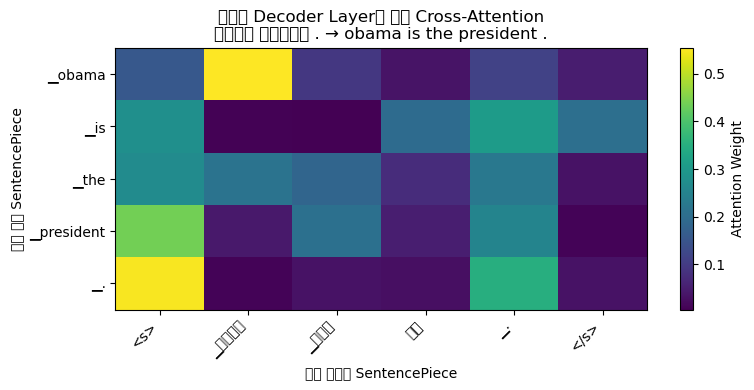

In [23]:
# 토큰 번호를 사람이 볼 수 있는 조각으로 바꾸는 함수
def token_pieces_from_ids(tokenizer, token_ids):
    # 결과 반환
    return [tokenizer.id_to_piece(token_id) for token_id in token_ids]


# Encoder Decoder Attention을 그림으로 보여주는 함수
def visualize_cross_attention(result):
    # 번역할 때 저장한 Cross-Attention을 꺼낸다
    attention = result['cross_attention']

    # 표시할 Attention 값이 있는지 확인
    if attention.numel() == 0:
        # 결과 출력
        print('표시할 Attention 값이 없습니다.')
        return

    # 여러 Head의 Attention 평균 계산
    mean_attention = attention.mean(dim=1).numpy()
    # 한국어 토큰 번호를 글자 조각으로 변환
    src_pieces = token_pieces_from_ids(ko_tokenizer, result['src_ids'])
    # 영어 토큰 번호를 글자 조각으로 변환
    tgt_pieces = token_pieces_from_ids(en_tokenizer, result['tgt_ids'])

    plt.figure(
        figsize=(
            max(8, len(src_pieces) * 0.7),
            max(4, len(tgt_pieces) * 0.55),
        )
    )
    plt.imshow(mean_attention, aspect='auto', interpolation='nearest', cmap='viridis')
    plt.colorbar(label='Attention Weight')
    plt.xticks(range(len(src_pieces)), src_pieces, rotation=45, ha='right')
    plt.yticks(range(len(tgt_pieces)), tgt_pieces)
    # x축 이름
    plt.xlabel('입력 한국어 SentencePiece')
    # y축 이름
    plt.ylabel('생성 영어 SentencePiece')
    # 그래프 제목
    plt.title(
        '마지막 Decoder Layer의 평균 Cross-Attention\n'
        f"{result['input_text']} → {result['translation']}"
    )
    # 그래프 글자가 겹치지 않게 정리
    plt.tight_layout()
    # 그래프 출력
    plt.show()


visualize_cross_attention(translation_results[0])


Head마다 보는 위치가 다른지 따로 확인한다

/tmp/ipykernel_1209/3365517940.py:45: UserWarning: Glyph 50724 (\N{HANGUL SYLLABLE O}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1209/3365517940.py:45: UserWarning: Glyph 48148 (\N{HANGUL SYLLABLE BA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1209/3365517940.py:45: UserWarning: Glyph 47560 (\N{HANGUL SYLLABLE MA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1209/3365517940.py:45: UserWarning: Glyph 45716 (\N{HANGUL SYLLABLE NEUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1209/3365517940.py:45: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1209/3365517940.py:45: UserWarning: Glyph 53685 (\N{HANGUL SYLLABLE TONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1209/3365517940.py:45: UserWarning: Glyph 47161 (\N{HANGUL SYLLABLE RYEONG}) missing from font(s) DejaVu Sans.
  plt.tight_

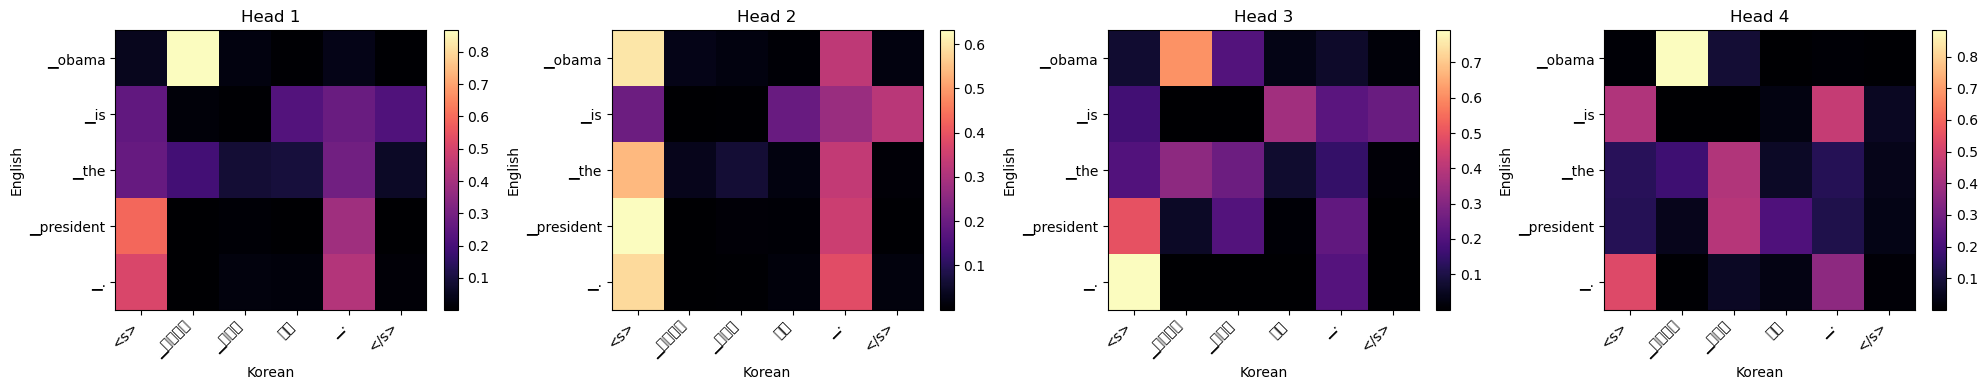

In [24]:
# Attention Head별로 어디를 보는지 비교하는 함수
def visualize_attention_heads(result, max_heads=4):
    # 번역할 때 저장한 Cross-Attention을 꺼낸다
    attention = result['cross_attention']

    # 표시할 Attention 값이 있는지 확인
    if attention.numel() == 0:
        # 결과 출력
        print('표시할 Attention 값이 없습니다.')
        return

    # 한국어 토큰 번호를 글자 조각으로 변환
    src_pieces = token_pieces_from_ids(ko_tokenizer, result['src_ids'])
    # 영어 토큰 번호를 글자 조각으로 변환
    tgt_pieces = token_pieces_from_ids(en_tokenizer, result['tgt_ids'])
    # 그림에 표시할 Head 개수 결정
    head_count = min(max_heads, attention.size(1))

    fig, axes = plt.subplots(
        1,
        head_count,
        figsize=(5 * head_count, max(4, len(tgt_pieces) * 0.5)),
        squeeze=False,
    )

    # Head를 하나씩 그림으로 확인
    for head_index in range(head_count):
        axis = axes[0, head_index]
        image = axis.imshow(
            attention[:, head_index, :].numpy(),
            aspect='auto',
            interpolation='nearest',
            cmap='magma',
        )
        axis.set_title(f'Head {head_index + 1}')
        axis.set_xticks(range(len(src_pieces)))
        axis.set_xticklabels(src_pieces, rotation=45, ha='right')
        axis.set_yticks(range(len(tgt_pieces)))
        axis.set_yticklabels(tgt_pieces)
        axis.set_xlabel('Korean')
        axis.set_ylabel('English')
        fig.colorbar(image, ax=axis, fraction=0.046)

    # 그래프 글자가 겹치지 않게 정리
    plt.tight_layout()
    # 그래프 출력
    plt.show()


visualize_attention_heads(translation_results[0], max_heads=4)


## 13. BLEU와 Test Loss 평가  

BLEU는 모델 번역과 정답 번역의 n-gram 겹침을 측정한다  

가능한 번역이 여러 개이므로 BLEU 하나만으로 품질을 단정하지 않고, Test Loss와 번역 샘플도 함께 확인한다  

전체 test 문장 번역은 시간이 걸릴 수 있어 기본값은 500개이다  

In [25]:
# BLEU 평가에 사용할 test 문장 개수
BLEU_MAX_SAMPLES = 100 if QUICK_RUN else 500

# test 문장을 번역하고 BLEU 점수를 계산하는 함수
# 평가할 때는 gradient 계산이 필요 없으니 잠시 끈다
@torch.no_grad()
def evaluate_bleu(test_pairs, max_samples=BLEU_MAX_SAMPLES):
    # BLEU 평가에 사용할 test 문장 선택
    selected_pairs = test_pairs if max_samples is None else test_pairs[:max_samples]
    # 모델이 번역한 영어 문장을 담을 리스트
    predictions = []
    # 정답 영어 문장을 담을 리스트
    references = []

    # test 문장을 하나씩 번역
    for ko, reference_en in tqdm(selected_pairs, desc='BLEU 번역 평가'):
        # 모델 번역 결과 저장
        predictions.append(greedy_translate(ko, model)['translation'])
        # 정답 영어 문장 저장
        references.append(reference_en)

    # 예측과 정답을 비교해 BLEU 계산
    bleu = sacrebleu.corpus_bleu(predictions, [references], tokenize='13a')
    # 결과 반환
    return bleu, predictions, references


bleu_score, bleu_predictions, bleu_references = evaluate_bleu(test_pairs)

# 결과 출력
print(f'평가 문장 수: {len(bleu_predictions):,}')
# 결과 출력
print(f'Corpus BLEU : {bleu_score.score:.2f}')

# 결과 출력
print('\n[번역 샘플 비교]')
# 번역 샘플을 앞에서 다섯 개까지 확인
for index in range(min(5, len(bleu_predictions))):
    # 결과 출력
    print('-' * 70)
    # 결과 출력
    print('정답:', bleu_references[index])
    # 결과 출력
    print('예측:', bleu_predictions[index])


BLEU 번역 평가:   0%|          | 0/500 [00:00<?, ?it/s]

That's 100 lines that end in a tokenized period ('.')
It looks like you forgot to detokenize your test data, which may hurt your score.
If you insist your data is detokenized, or don't care, you can suppress this message with the `force` parameter.


평가 문장 수: 500
Corpus BLEU : 6.01

[번역 샘플 비교]
----------------------------------------------------------------------
정답: those involved in the discussions do take seriously the need to address concerns of law enforcement and national security .
예측: some of those who are concerned about the security and security of the national security council , are concerned about the need to be done .
----------------------------------------------------------------------
정답: there is also some hope that new technology developments will help to provide some solutions and at the same time helping to make users of the networks more secure in their communications .
예측: new technology also help people get more to work , and we hope to help help the information that can help you get to the telecommunications .
----------------------------------------------------------------------
정답: so the individual solution of the clipper chip may fade from sight , but the questions will be with us and will remain serious

test loss와 학습 요약을 저장

In [26]:
# test 데이터의 loss와 토큰 정확도 계산
test_loss, test_accuracy = evaluate_one_epoch(model, test_loader, criterion)

# 결과 출력
print(f'Test Loss          : {test_loss:.4f}')
print(f'Test Token Accuracy: {test_accuracy:.4f}')
print(f'Corpus BLEU        : {bleu_score.score:.2f}')

# 학습 결과를 한곳에 정리한다
summary = {
    'model_path': str(MODEL_PATH),
    'ko_tokenizer': str(TOKENIZER_DIR / 'ko_spm.model'),
    'en_tokenizer': str(TOKENIZER_DIR / 'en_spm.model'),
    'train_pairs_after_length_filter': len(train_encoded),
    'valid_pairs_after_length_filter': len(valid_encoded),
    'test_pairs_after_length_filter': len(test_encoded),
    'best_valid_loss': checkpoint['best_valid_loss'],
    'test_loss': test_loss,
    'test_token_accuracy': test_accuracy,
    'bleu': bleu_score.score,
    'quick_run': QUICK_RUN,
}

# 학습 요약을 저장할 파일 경로
summary_path = MODEL_DIR / 'training_summary.json'
# 학습 요약 JSON 파일을 연다
with open(summary_path, 'w', encoding='utf-8') as file:
    # 한글이 깨지지 않게 학습 결과 저장
    json.dump(summary, file, ensure_ascii=False, indent=2)

# 결과 출력
print('\n학습 요약 저장:', summary_path)


Valid:   0%|          | 0/30 [00:00<?, ?it/s]

Test Loss          : 4.4673
Test Token Accuracy: 0.3678
Corpus BLEU        : 6.01

학습 요약 저장: /home/jovyan/work/ko_en_transformer/model/training_summary.json


# 코드 요약

이번 프로젝트에서는 한국어 문장을 영어로 번역하는 Transformer 번역기를 구현했다.

먼저 한·영 병렬 말뭉치를 불러온 뒤 공백, 따옴표, 중복 문장과 비정상적인 문장을 정리했다  

이후 SentencePiece를 사용해 한국어와 영어 문장을 서브워드 단위로 나누고, 각 토큰을 정수 ID로 변환했다  

문장의 시작과 끝을 구분하기 위해 BOS와 EOS 토큰을 추가하고, 길이가 다른 문장들은 PAD 토큰을 사용해 하나의 배치로 만들었다  

Transformer 모델에서는 Positional Encoding, Multi-Head Attention, Feed Forward Network, Encoder와 Decoder를 직접 구현했다  

Encoder에서는 한국어 문장의 전체 문맥을 학습하고, Decoder에서는 이전에 생성된 영어 토큰과 Encoder의 결과를 참고해 다음 영어 토큰을 예측하도록 만들었다  

Decoder가 학습 중 미래의 정답을 미리 보지 못하도록 Causal Mask를 적용했고, 문장의 PAD 부분을 참고하지 않도록 Padding Mask도 함께 사용했다  

모델 학습에는 Teacher Forcing, Noam Learning Rate, Gradient Clipping, Early Stopping을 적용했다  

학습이 끝난 뒤에는 Greedy Decoding을 사용해 BOS 토큰부터 영어 단어를 하나씩 생성하고, EOS 토큰이 나오면 번역을 종료하도록 했다  

또한 Encoder-Decoder Attention Map을 시각화해 영어 토큰을 생성할 때 한국어 문장의 어느 부분을 참고했는지 확인했다  

최종적으로 Test Loss는 4.4673, Test Token Accuracy는 약 36.78%, BLEU 점수는 6.01이 나왔다  

짧고 단순한 문장은 비교적 자연스럽게 번역했지만, 길고 복잡한 문장에서는 같은 단어가 반복되거나 원문의 의미가 일부 달라지는 모습도 확인할 수 있었다  

번역 결과 예시  

오바마는 대통령이다.  

→ obama is the president.  

커피는 필요 없다.  

→ coffee is not needed.  

일곱 명의 사망자가 발생했다.  

→ seven people were killed.  

시민들은 도시 속에 산다.  

→ people are living in the town of cities.  

딥러닝 수업은 재미있다.  

→ the trash is a fun, " he said.  

앞의 세 문장은 의미가 잘 전달되었지만, 마지막 두 문장은 어색하거나 원래 의미와 다른 번역이 생성되었다  

이를 통해 모델이 짧고 학습 데이터와 비슷한 문장에는 강하지만, 익숙하지 않은 표현에는 아직 약하다는 것을 알 수 있었다  

# 회고

이번 프로젝트를 진행하면서 Transformer가 단순히 하나의 모델을 불러와 사용하는 것이 아니라, 여러 개의 작은 기능이 연결되어 동작한다는 것을 알게 되었다  

처음에는 Attention, Encoder, Decoder, Mask의 역할이 각각 따로 느껴졌지만 직접 코드를 구현하고 텐서 모양을 확인하면서 전체 흐름을 조금씩 이해할 수 있었다  

가장 오래 걸리고 어려웠던 부분은 SentencePiece 토크나이저 학습이었다  

전체 문장과 큰 vocabulary를 사용하자 실행 시간이 너무 길어졌고, 처음에는 코드가 멈춘 것처럼 보였다  

토크나이저 학습에 사용하는 문장 수를 30,000개로 줄이고 vocabulary 크기를 조절하자 정상적으로 실행되었다  

이를 통해 데이터가 많다고 무조건 좋은 것이 아니라, 현재 환경의 성능과 학습 목적에 맞게 크기를 조절해야 한다는 것을 배웠다.  

또한 Causal Mask와 Padding Mask의 방향을 이해하는 부분이 어려웠다  

Mask가 반대로 적용되면 Decoder가 미래 정답을 보거나 필요한 토큰까지 가릴 수 있기 때문에, 작은 예시를 그림으로 출력해 직접 확인하는 과정이 필요했다  

단순히 코드가 오류 없이 실행되는 것보다 모델이 의도한 방식으로 동작하는지 확인하는 것이 더 중요하다는 점을 느꼈다.  

모델 학습 결과 Train Loss와 Validation Loss가 계속 감소했고, 번역 문장도 실제로 출력되었다  

특히 오바마는 대통령이다.와 커피는 필요 없다. 같은 문장은 자연스럽게 번역되어 Transformer가 문장의 관계를 어느 정도 학습했다는 것을 확인할 수 있었다  

반면 딥러닝 수업은 재미있다.라는 문장은 원래 의미와 전혀 다른 결과가 나왔다  

이번에 사용한 데이터가 뉴스 기사 중심이기 때문에 일상적인 문장이나 학습 데이터에 자주 등장하지 않은 표현에는 약한 것으로 보인다  

BLEU 점수도 6.01로 높지 않았기 때문에 번역기가 기본적인 문장 구조는 학습했지만, 아직 다양한 문장을 안정적으로 번역할 정도는 아니라고 생각한다  

Attention Map에서는 영어 단어를 생성할 때 관련된 한국어 토큰에 비교적 높은 Attention이 나타나는 것을 확인했다  

하지만 모든 단어가 정확하게 대응되는 것은 아니었고, 일부 Head는 BOS나 문장부호에 Attention이 많이 모이기도 했다  

그래도 숫자로만 보던 Attention을 그림으로 확인하니 모델이 입력 문장을 참고하는 방식을 조금 더 이해할 수 있었다  

이번 프로젝트에서 가장 크게 배운 점은 모델을 만드는 것뿐만 아니라 데이터 전처리, 토큰화, Mask, 학습 과정, 추론 방법이 모두 번역 결과에 영향을 준다는 것이다  

다음에는 한국어와 영어 토크나이저의 vocabulary 크기를 동일하게 맞추고, 문장부호의 공백을 제거한 뒤 BLEU를 다시 계산해 보고 싶다  

또한 학습 데이터를 더 다양하게 구성하고 Beam Search를 적용해 Greedy Decoding보다 자연스러운 번역이 나오는지도 비교해 보고 싶다  

처음에는 코드가 길고 복잡해서 전체 구조를 이해하기 어려웠지만, 각 부분을 나누어 실행하고 결과를 확인하면서 Transformer 번역기의 흐름을 직접 경험할 수 있었다  

완벽한 번역기는 아니지만 데이터 준비부터 모델 학습, 실제 번역, Attention 시각화와 평가까지 모두 수행했다는 점에서 의미 있는 프로젝트였다  